### **_Telco Customer Churn Prediction_**

**_Dataset: `WA_Fn-UseC_-Telco-Customer-Churn.csv`_**

**_The dataset contains customer information from a telecom company and aims to predict whether a customer will churn (leave the service)._**

**_Each row represents a customer, and each column represents attributes such as:_**

- **_Services subscribed (phone, internet, streaming, etc.)_**
- **_Account information (tenure, contract type, payment method)_**
- **_Billing information (monthly and total charges)_**
- **_Demographic details (gender, senior citizen status, dependents)_**

**_The target variable is Churn, indicating whether the customer left within the last month._**

**_The goal is to develop models that identify high-risk customers to support proactive retention strategies._**

### **_Setup_**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTENC
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,roc_auc_score, roc_curve, auc
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

### **_configurations_**

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

RANDOM_STATE = 42
CSV_PATH="../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
TARGET_COL="Churn"

In [3]:
df = pd.read_csv(CSV_PATH)
print(f'Dataset shape: {df.shape}')

Dataset shape: (7043, 21)


In [4]:
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


### **_Exploratory Data Analysis_**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# dropping customerID column as this is not required for modelling

df = df.drop(columns=["customerID"])

In [7]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
# printing the unique values in all the columns

numerical_features_list = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in df.columns:
  if col not in numerical_features_list:
    print(col, df[col].unique())
    print("-"*50)

gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
--------------------------------------------------
TechSupport ['No' 'Yes' 'No internet service']
--------------------------------------------------
StreamingTV ['No' 'Yes' 'No internet 

In [9]:
df.isna().sum().sort_values()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
# df["TotalCharges"] = df["TotalCharges"].astype(float)

In [11]:
df[df["TotalCharges"]==" "]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.550,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.250,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.850,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.750,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.050,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.850,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.350,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.000,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.700,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.350,,No


In [12]:
len(df[df["TotalCharges"]==" "])

11

In [13]:
df["TotalCharges"] = df["TotalCharges"].replace({" ": "0.0"})

In [14]:
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [16]:
# checking the class distribution of target column

print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [17]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [18]:
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


**_Insights:_**
1. **_Customer ID removed as it is not required for modelling_**
2. **_No mmissing values in the dataset_**
3. **_Missing values in the TotalCharges column were replaced with 0_**
4. **_Class imbalance identified in the target_**

In [19]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000,7043.000,7043.000,7043.000,7043.000
mean,0.162,32.371,64.762,2279.734,0.265
std,0.369,24.559,30.090,2266.794,0.442
min,0.000,0.000,18.250,0.000,0.000
25%,0.000,9.000,35.500,398.550,0.000
50%,0.000,29.000,70.350,1394.550,0.000
75%,0.000,55.000,89.850,3786.600,1.000
max,1.000,72.000,118.750,8684.800,1.000


### **_Categorical Count Plots_**

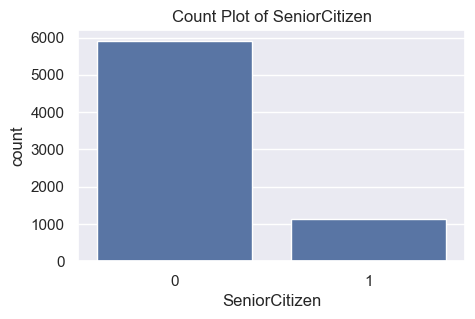

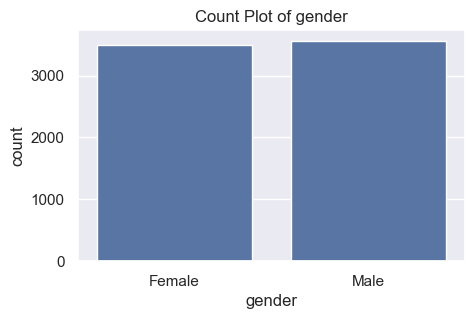

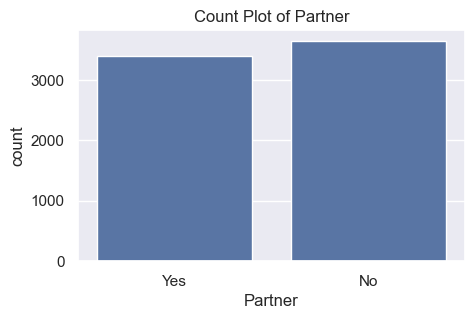

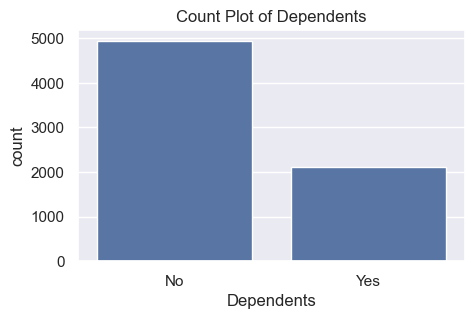

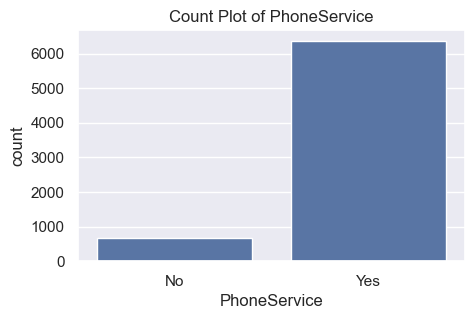

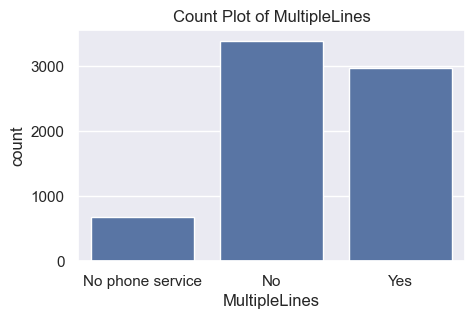

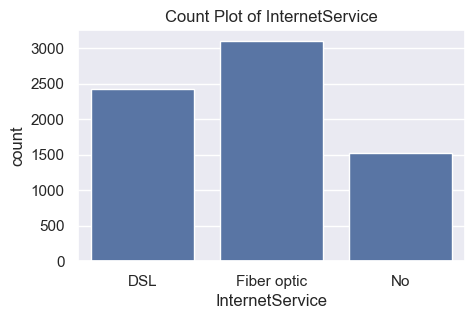

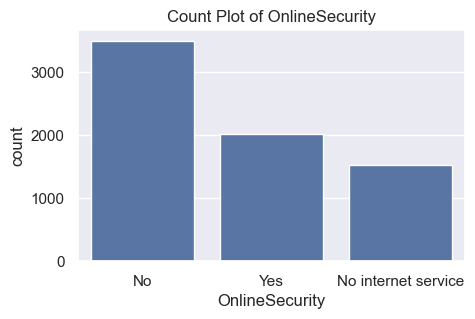

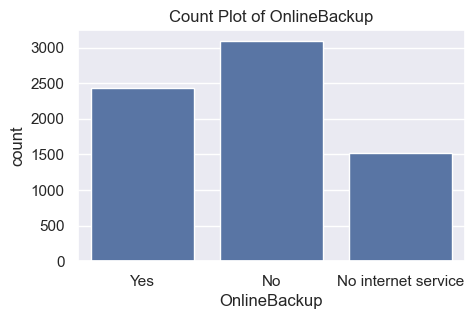

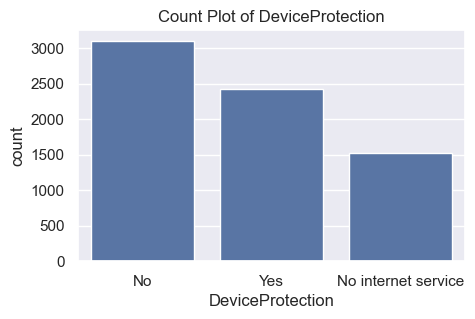

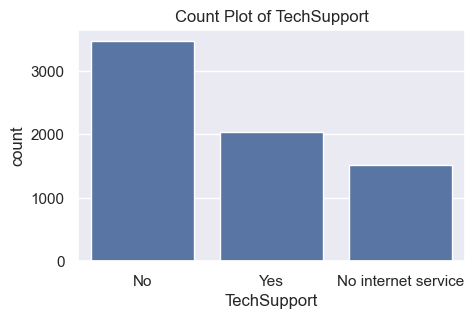

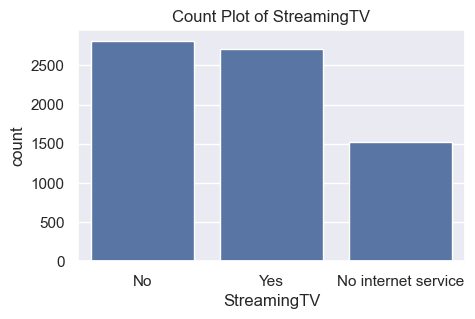

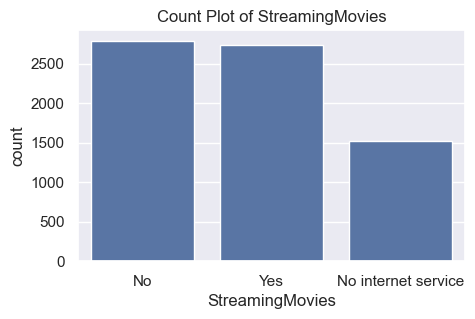

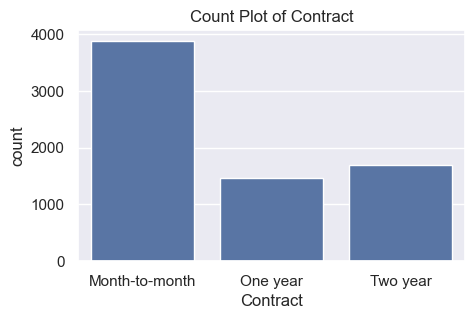

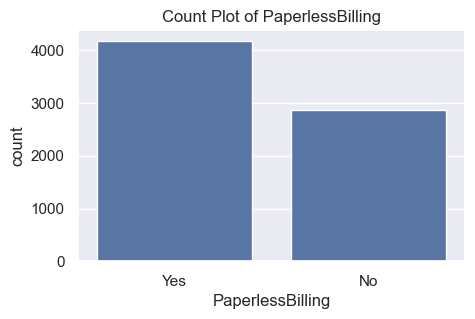

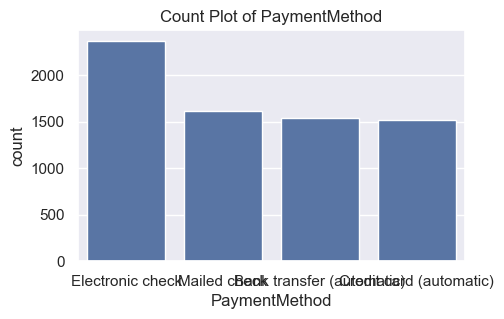

In [20]:
object_cols = df.select_dtypes(include="object").columns.to_list()
object_cols = ["SeniorCitizen"] + object_cols

for col in object_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.show()

**_Boxplot Function_**

In [21]:
def plot_boxplot(df, column_name):
    plt.figure(figsize=(5, 3))
    sns.boxplot(y=df[column_name])
    plt.title(f"Box Plot of {column_name}")
    plt.ylabel(column_name)
    plt.show()

**_Histogram Function (Mean + Median)_**

In [22]:
def plot_histogram(df, column_name):
    plt.figure(figsize=(5, 3))
    sns.histplot(df[column_name], kde=True)
    plt.title(f"Distribution of {column_name}")

    col_mean = df[column_name].mean()
    col_median = df[column_name].median()

    plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
    plt.axvline(col_median, color="green", linestyle="-", label="Median")

    plt.legend()
    plt.show()

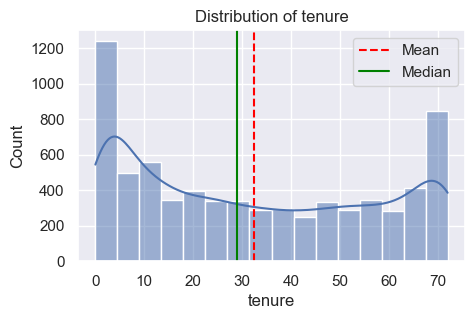

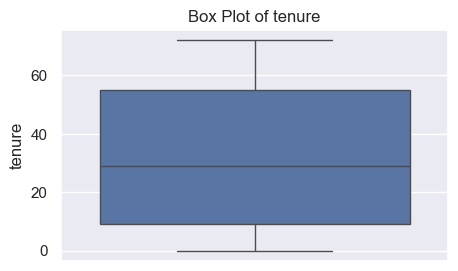

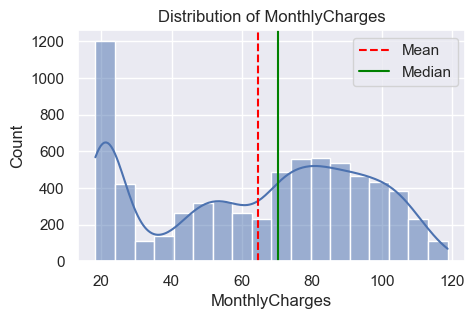

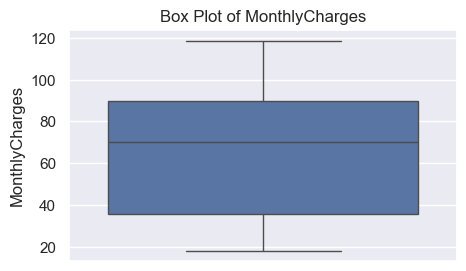

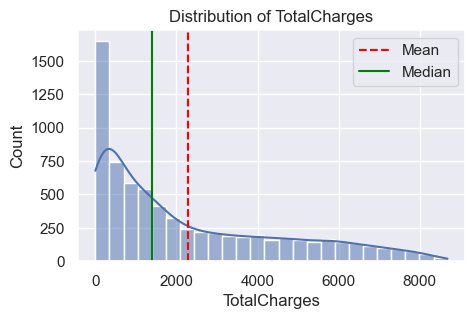

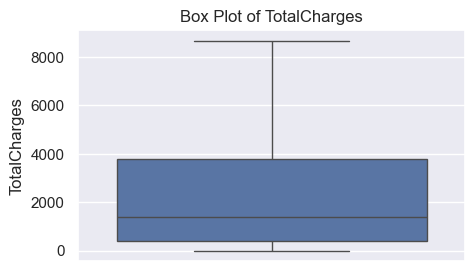

In [23]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    plot_histogram(df, col)
    plot_boxplot(df, col)

**_Multicollinearity Check — VIF_**

In [24]:
X_vif = df[num_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vif)

vif_data = pd.DataFrame()
vif_data["Feature"] = num_cols
vif_data["VIF"] = [
    variance_inflation_factor(X_scaled, i)
    for i in range(X_scaled.shape[1])
]

vif_data

,Feature,VIF
0,tenure,5.837
1,MonthlyCharges,3.217
2,TotalCharges,9.511


* **_TotalCharges shows high multicollinearity (VIF ≈ 9.5), likely because it is derived from tenure and MonthlyCharges._**
* **_tenure has moderate correlation (VIF ≈ 5.8)._**
* **_MonthlyCharges shows low multicollinearity and is an independent predictor._**
* **_Since tree-based models (Random Forest, XGBoost) are robust to multicollinearity, all features were retained for modeling_**

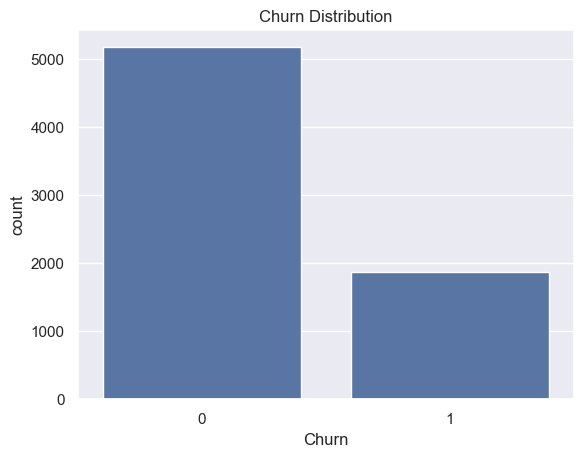

In [25]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

### **_Data Preprocessing_**

In [26]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

**_Class Imbalance - Identify Categorical Columns (for SMOTENC)_**

In [28]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

In [29]:
cat_indices = [X.columns.get_loc(col) for col in cat_cols]

In [30]:
smote_nc = SMOTENC(categorical_features=cat_indices, random_state=RANDOM_STATE)

In [31]:
# Preprocessing Pipeline

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

### **_Baseline Model - Logistic Regression_**

In [32]:
base_pipe = ImbPipeline(
    steps=[
        ('smote', smote_nc),
        ('prep', preprocessor),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

In [33]:
base_pipe.fit(X_train, y_train)

,steps,"[('smote', ...), ('prep', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,categorical_features,"[0, 2, ...]"
,categorical_encoder,None
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'


**_reusable evaluation function_**

In [34]:
def evaluate_classifier(model, X_train, y_train, X_test, y_test, model_name):
    # predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # accuracy
    train_acc = accuracy_score(y_train, y_train_pred) * 100
    test_acc = accuracy_score(y_test, y_test_pred) * 100

    # results
    print(f"{model_name} - Train Accuracy: {train_acc:.2f}%")
    print(f"{model_name} - Test Accuracy: {test_acc:.2f}%\n")

    print("-"*40)

    print("Train Classification Report")
    print(classification_report(y_train, y_train_pred))

    print("-"*40)

    print("Test Classification Report")
    print(classification_report(y_test, y_test_pred))

In [35]:
evaluate_classifier(base_pipe, X_train, y_train, X_test, y_test, model_name="Logistic Regression - Base Model")

Logistic Regression - Base Model - Train Accuracy: 76.59%
Logistic Regression - Base Model - Test Accuracy: 74.66%

----------------------------------------
Train Classification Report
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      4139
           1       0.54      0.73      0.62      1495

    accuracy                           0.77      5634
   macro avg       0.72      0.76      0.73      5634
weighted avg       0.80      0.77      0.78      5634

----------------------------------------
Test Classification Report
              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1035
           1       0.52      0.72      0.60       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.75      0.76      1409



### **_Model Selection_**

In [36]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()

In [37]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [38]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, scale_pos_weight=ratio, use_label_encoder=False, eval_metric='logloss')
}

In [39]:
results = []

for name, model in models.items():

    recall_scores = []
    f1_scores = []
    roc_scores = []  

    for tr_idx, te_idx in cv.split(X_train, y_train):

        X_tr = X_train.iloc[tr_idx]
        X_te = X_train.iloc[te_idx]
        y_tr = y_train.iloc[tr_idx]
        y_te = y_train.iloc[te_idx]

        pipeline = ImbPipeline(
            steps=[
                ("smote", smote_nc),        
                ("prep", preprocessor),  
                ("model", model)
            ]
        )

        pipeline.fit(X_tr, y_tr)

        
        pred = pipeline.predict(X_te)
        prob = pipeline.predict_proba(X_te)[:, 1] 

        recall_scores.append(round(recall_score(y_te, pred), 3))
        f1_scores.append(round(f1_score(y_te, pred), 3))
        roc_scores.append(round(roc_auc_score(y_te, prob), 3))

    recall_mean = round(float(np.mean(recall_scores)), 4)
    f1_mean = round(float(np.mean(f1_scores)), 4)
    roc_mean = round(float(np.mean(roc_scores)), 4)

    print("Model name:", name)
    print("Recall values:", recall_scores)
    print("F1 scores:", f1_scores)
    print("ROC-AUC values:", roc_scores)

    print("\nCV Recall mean:", recall_mean)
    print("CV F1 Score mean:", f1_mean)
    print("CV ROC-AUC mean:", roc_mean)

    print("-"*60)

    results.append([
        name,
        recall_scores,
        f1_scores,
        roc_scores,
        recall_mean,
        f1_mean,
        roc_mean
    ])

Model name: Decision Tree
Recall values: [0.589, 0.502, 0.575, 0.562, 0.525]
F1 scores: [0.533, 0.485, 0.524, 0.532, 0.495]
ROC-AUC values: [0.682, 0.648, 0.677, 0.681, 0.658]

CV Recall mean: 0.5506
CV F1 Score mean: 0.5138
CV ROC-AUC mean: 0.6692
------------------------------------------------------------
Model name: Random Forest
Recall values: [0.579, 0.538, 0.602, 0.592, 0.562]
F1 scores: [0.569, 0.555, 0.596, 0.578, 0.574]
ROC-AUC values: [0.81, 0.804, 0.814, 0.814, 0.832]

CV Recall mean: 0.5746
CV F1 Score mean: 0.5744
CV ROC-AUC mean: 0.8148
------------------------------------------------------------
Model name: XGBoost
Recall values: [0.712, 0.645, 0.722, 0.746, 0.679]
F1 scores: [0.617, 0.568, 0.608, 0.624, 0.594]
ROC-AUC values: [0.817, 0.808, 0.818, 0.836, 0.822]

CV Recall mean: 0.7008
CV F1 Score mean: 0.6022
CV ROC-AUC mean: 0.8202
------------------------------------------------------------


In [40]:
cv_results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Recall per Fold",
        "F1 per Fold",
        "ROC-AUC per Fold",
        "CV Recall Mean",
        "CV F1 Mean",
        "CV ROC-AUC Mean"
    ]
)

cv_results_df

,Model,Recall per Fold,F1 per Fold,ROC-AUC per Fold,CV Recall Mean,CV F1 Mean,CV ROC-AUC Mean
0,Decision Tree,"[0.589, 0.502, 0.575, 0.562, 0.525]","[0.533, 0.485, 0.524, 0.532, 0.495]","[0.682, 0.648, 0.677, 0.681, 0.658]",0.551,0.514,0.669
1,Random Forest,"[0.579, 0.538, 0.602, 0.592, 0.562]","[0.569, 0.555, 0.596, 0.578, 0.574]","[0.81, 0.804, 0.814, 0.814, 0.832]",0.575,0.574,0.815
2,XGBoost,"[0.712, 0.645, 0.722, 0.746, 0.679]","[0.617, 0.568, 0.608, 0.624, 0.594]","[0.817, 0.808, 0.818, 0.836, 0.822]",0.701,0.602,0.820


In [41]:
cv_results_df.sort_values("CV ROC-AUC Mean", ascending=False)

,Model,Recall per Fold,F1 per Fold,ROC-AUC per Fold,CV Recall Mean,CV F1 Mean,CV ROC-AUC Mean
2,XGBoost,"[0.712, 0.645, 0.722, 0.746, 0.679]","[0.617, 0.568, 0.608, 0.624, 0.594]","[0.817, 0.808, 0.818, 0.836, 0.822]",0.701,0.602,0.820
1,Random Forest,"[0.579, 0.538, 0.602, 0.592, 0.562]","[0.569, 0.555, 0.596, 0.578, 0.574]","[0.81, 0.804, 0.814, 0.814, 0.832]",0.575,0.574,0.815
0,Decision Tree,"[0.589, 0.502, 0.575, 0.562, 0.525]","[0.533, 0.485, 0.524, 0.532, 0.495]","[0.682, 0.648, 0.677, 0.681, 0.658]",0.551,0.514,0.669


>**_XGBoost provides the highest performance_**


Model: Decision Tree


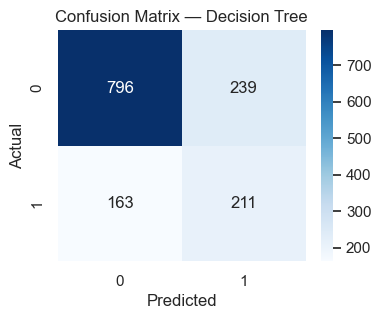

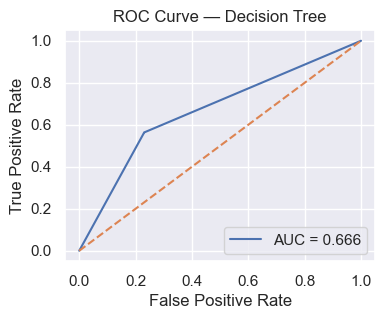


Model: Random Forest


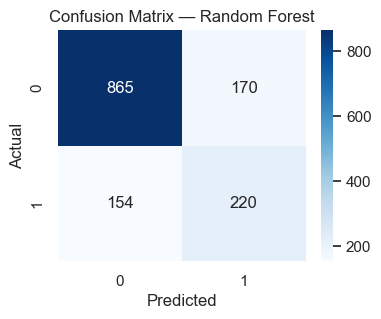

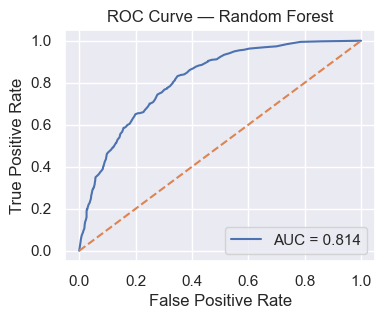


Model: XGBoost


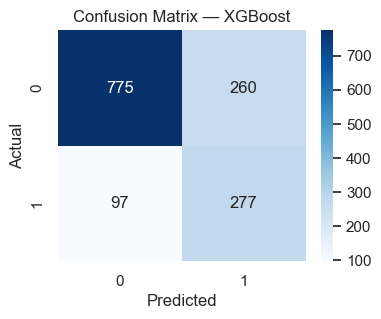

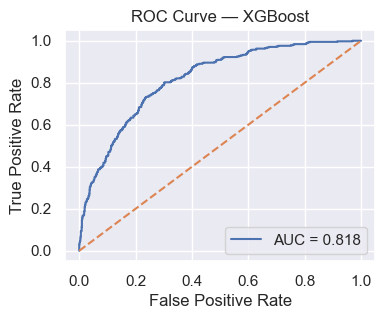

In [42]:
for name, model in models.items():

    print("\nModel:", name)

    pipeline = ImbPipeline(
        steps=[
            ("smote", smote_nc),
            ("prep", preprocessor),
            ("model", model)
        ]
    )

    # Train on full training set
    pipeline.fit(X_train, y_train)

    # Predictions on TEST set
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(4, 3))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.title(f"ROC Curve — {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.show()

### **_Hyperparameter Tuning - XGB_**

In [43]:
xgb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 6],
    'model__learning_rate': [0.01, 0.1],
    'model__subsample': [0.8, 1.0]
}

In [44]:
xgb_pipeline = ImbPipeline([
    ('smote', smote_nc),
    ('prep', preprocessor),
    ('model', XGBClassifier(random_state=RANDOM_STATE, scale_pos_weight=ratio, use_label_encoder=False, eval_metric='logloss'))
])

### **_GridSearchCV_**

In [45]:
xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

In [46]:
xgb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.1], 'model__max_depth': [3, 6], 'model__n_estimators': [100, 200], 'model__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fo

In [47]:
print("Hyperparameter Tuning result:")
print(f'Best params: {xgb_grid.best_params_}')
print(f'Best score: {xgb_grid.best_score_}')

Hyperparameter Tuning result:
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 1.0}
Best score: 0.8398083111839989


### **_Retrain with best params_**

In [48]:
xgb_best = ImbPipeline(
    steps=[
        ("smote", smote_nc),
        ("prep", preprocessor),
        ("model", XGBClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,

            n_estimators=xgb_grid.best_params_["model__n_estimators"],
            max_depth=xgb_grid.best_params_["model__max_depth"],
            learning_rate=xgb_grid.best_params_["model__learning_rate"],
            subsample=xgb_grid.best_params_["model__subsample"],

            scale_pos_weight=ratio,
            use_label_encoder=False,
            eval_metric='logloss'
        ))
    ]
)

In [49]:
xgb_best.fit(X_train, y_train)

,steps,"[('smote', ...), ('prep', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,categorical_features,"[0, 2, ...]"
,categorical_encoder,None
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'


### **_Model Evaluation_**

In [50]:
evaluate_classifier(xgb_best, X_train, y_train, X_test, y_test, model_name="XGBOOST - Best Model")

XGBOOST - Best Model - Train Accuracy: 71.76%
XGBOOST - Best Model - Test Accuracy: 69.62%

----------------------------------------
Train Classification Report
              precision    recall  f1-score   support

           0       0.95      0.65      0.77      4139
           1       0.48      0.90      0.63      1495

    accuracy                           0.72      5634
   macro avg       0.72      0.78      0.70      5634
weighted avg       0.82      0.72      0.73      5634

----------------------------------------
Test Classification Report
              precision    recall  f1-score   support

           0       0.93      0.64      0.76      1035
           1       0.46      0.86      0.60       374

    accuracy                           0.70      1409
   macro avg       0.69      0.75      0.68      1409
weighted avg       0.80      0.70      0.71      1409



### **_Build a predictive system_**

In [51]:
def predict_churn(input_features):
    """
    Predict churn for a single customer using trained pipeline (xgb_best)
    input_features → list of feature values in SAME order as X_train columns
    """

    input_df = pd.DataFrame(
        [input_features],
        columns=X_train.columns
    )

    prediction = xgb_best.predict(input_df)[0]

    probability = xgb_best.predict_proba(input_df)[0][1]

    print(f"Predicted class: {prediction}")
    print(f"Churn probability: {probability:.2%}")
    
    if prediction == 1:
        print("Diagnosis: Customer likely to churn ⚠️")
    else:
        print("Diagnosis: Customer likely to stay ✅")

    result = {
        "prediction": int(prediction),
        "probability": float(probability),
        "risk_level": "High" if prediction == 1 else "Low"
    }

    print("\n--- CUSTOMER CHURN PREDICTION ---")
    print(f"Prediction      : {result['prediction']}")
    print(f"Probability     : {result['probability']:.2%}")
    print(f"Risk Level      : {result['risk_level']}")

    return result

In [52]:
test_1 = X_test.iloc[3].tolist()
print(test_1)

['Male', np.int64(0), 'Yes', 'No', np.int64(18), 'Yes', 'No', 'Fiber optic', 'No', 'No', 'Yes', 'Yes', 'No', 'No', 'Month-to-month', 'No', 'Electronic check', np.float64(78.2), np.float64(1468.75)]


In [53]:
predict_churn(test_1)

Predicted class: 1
Churn probability: 64.15%
Diagnosis: Customer likely to churn ⚠️

--- CUSTOMER CHURN PREDICTION ---
Prediction      : 1
Probability     : 64.15%
Risk Level      : High


{'prediction': 1, 'probability': 0.6415233016014099, 'risk_level': 'High'}

In [54]:
test_2 = X_test.iloc[4].tolist()
print(test_2)

['Female', np.int64(0), 'Yes', 'No', np.int64(72), 'Yes', 'Yes', 'DSL', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Two year', 'Yes', 'Credit card (automatic)', np.float64(82.65), np.float64(5919.35)]


In [55]:
predict_churn(test_2)

Predicted class: 0
Churn probability: 1.58%
Diagnosis: Customer likely to stay ✅

--- CUSTOMER CHURN PREDICTION ---
Prediction      : 0
Probability     : 1.58%
Risk Level      : Low


{'prediction': 0, 'probability': 0.015797076746821404, 'risk_level': 'Low'}